# Week 10

For this week, include the following ideas: k-means; specifically elbow method, Silhouette score, feature scaling, and distance metrics. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import classification_report

In [3]:
random_state = 42

## ECC

### Import Dataset

In [4]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
# df = pd.read_csv('/Users/calebhadley/Downloads/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
X = df.drop(columns='Class')
y = df['Class']

### Undersample

In [6]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.01, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
df_resampled = X_resampled.join(y_resampled)
print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 49200, 1: 492})


### Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### K Means

For K=2, the Silhouette Score is: 0.7122
For K=3, the Silhouette Score is: 0.6310
For K=4, the Silhouette Score is: 0.5874
For K=5, the Silhouette Score is: 0.5745
For K=6, the Silhouette Score is: 0.5588
For K=7, the Silhouette Score is: 0.5644


Text(0.5, 1.0, 'The Elbow Method showing the optimal K')

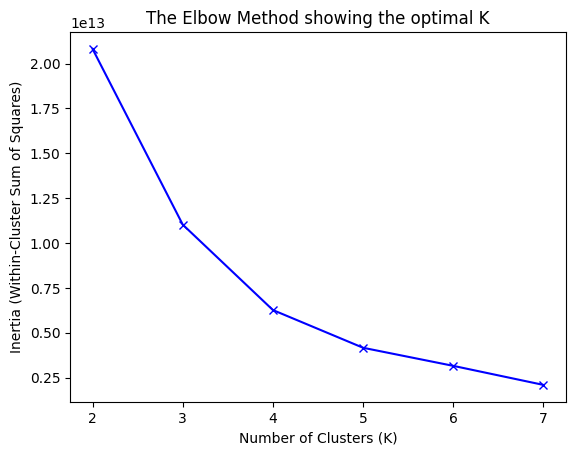

In [7]:
from sklearn.metrics import silhouette_score


inertia_values = []
K_range = range(2, 8)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(X_resampled)
    inertia_values.append(model.inertia_)

    cluster_labels = model.predict(X_resampled)
    score = silhouette_score(X_resampled, cluster_labels, metric='euclidean')
    
    print(f"For K={k}, the Silhouette Score is: {score:.4f}")

# Plot the elbow curve
plt.plot(K_range, inertia_values, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal K')

Using the eblow trick k = 3 looks to be the best value. Using the sillouette score k = 2 is the best value. 

In [8]:
kmeans = KMeans(n_clusters=2, random_state=random_state, n_init="auto")
kmeans.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [9]:
# Calculate distances to assigned centroids
# .transform() returns the distance from each point to EVERY centroid
distances_to_all_centroids = kmeans.transform(X_scaled)

# Isolate only the distance to the closest centroid (the assigned cluster)
labels = kmeans.labels_
anomaly_scores = distances_to_all_centroids[np.arange(len(X_scaled)), labels]

# Define an anomaly threshold
threshold_percentage = 95
threshold = np.percentile(anomaly_scores, threshold_percentage)

# Flag anomalies
is_anomaly = anomaly_scores > threshold

# View results
anomaly_df = pd.DataFrame(df_resampled)
anomaly_df['Anomaly_Score'] = anomaly_scores
anomaly_df['Is_Anomaly'] = is_anomaly

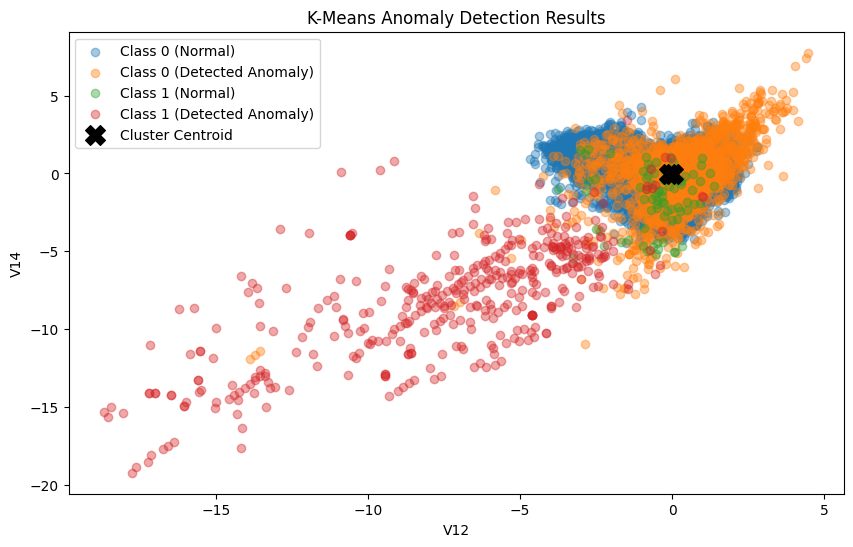

In [10]:
import matplotlib.pyplot as plt

# Separate the dataset into normal points and anomalies
normal_points = df_resampled[~is_anomaly]
anomaly_points = df_resampled[is_anomaly]

# Revert the scaled centroids back to the original data scale for accurate plotting
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X_resampled.columns)

feature_1 = 'V12'
feature_2 = 'V14'

# Initialize the plot
plt.figure(figsize=(10, 6))

c0_normal = anomaly_df[(anomaly_df['Class'] == 0) & (anomaly_df['Is_Anomaly'] == False)]

# Group 2: Class 0, Flagged as Anomaly
c0_anomaly = anomaly_df[(anomaly_df['Class'] == 0) & (anomaly_df['Is_Anomaly'] == True)]

# Group 3: Class 1, Normal
c1_normal = anomaly_df[(anomaly_df['Class'] == 1) & (anomaly_df['Is_Anomaly'] == False)]

# Group 4: Class 1, Flagged as Anomaly
c1_anomaly = anomaly_df[(anomaly_df['Class'] == 1) & (anomaly_df['Is_Anomaly'] == True)]

# Group 1: Class 0 - Not detected as anomaly (Blue Circles)
plt.scatter(c0_normal[feature_1], c0_normal[feature_2], 
            alpha=0.4, 
            label='Class 0 (Normal)')

# Group 2: Class 0 - Detected as anomaly (Red Circles)
plt.scatter(c0_anomaly[feature_1], c0_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 0 (Detected Anomaly)')

# Group 3: Class 1 - Not detected as anomaly (Blue Squares)
plt.scatter(c1_normal[feature_1], c1_normal[feature_2], 
            alpha=0.4, 
            label='Class 1 (Normal)')

# Group 4: Class 1 - Detected as anomaly (Red Squares)
plt.scatter(c1_anomaly[feature_1], c1_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 1 (Detected Anomaly)')

plt.scatter(centroids_df[feature_1], centroids_df[feature_2], 
            c='black', marker='X', s=200, label='Cluster Centroid')

# Final formatting
plt.title('K-Means Anomaly Detection Results')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
None

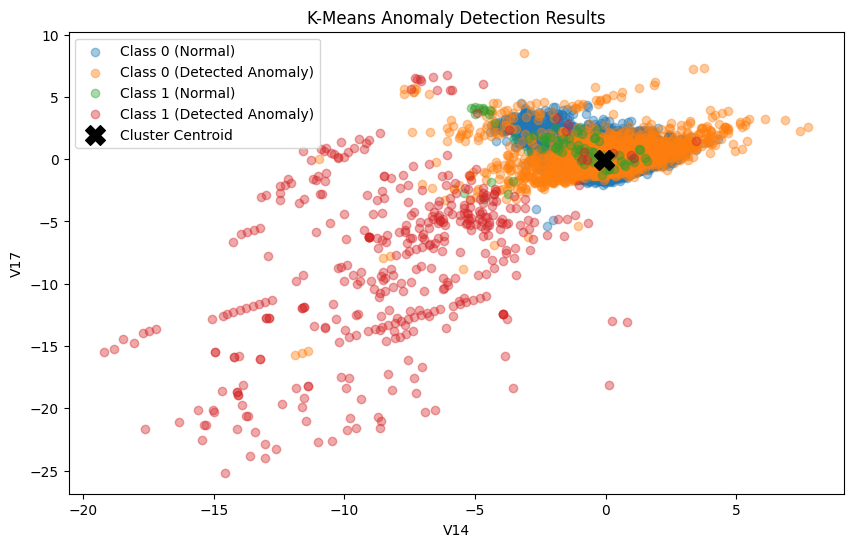

In [11]:
import matplotlib.pyplot as plt

# Separate the dataset into normal points and anomalies
normal_points = df_resampled[~is_anomaly]
anomaly_points = df_resampled[is_anomaly]

# Revert the scaled centroids back to the original data scale for accurate plotting
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X_resampled.columns)

feature_1 = 'V14'
feature_2 = 'V17'

# Initialize the plot
plt.figure(figsize=(10, 6))

c0_normal = anomaly_df[(anomaly_df['Class'] == 0) & (anomaly_df['Is_Anomaly'] == False)]

# Group 2: Class 0, Flagged as Anomaly
c0_anomaly = anomaly_df[(anomaly_df['Class'] == 0) & (anomaly_df['Is_Anomaly'] == True)]

# Group 3: Class 1, Normal
c1_normal = anomaly_df[(anomaly_df['Class'] == 1) & (anomaly_df['Is_Anomaly'] == False)]

# Group 4: Class 1, Flagged as Anomaly
c1_anomaly = anomaly_df[(anomaly_df['Class'] == 1) & (anomaly_df['Is_Anomaly'] == True)]

# Group 1: Class 0 - Not detected as anomaly (Blue Circles)
plt.scatter(c0_normal[feature_1], c0_normal[feature_2], 
            alpha=0.4, 
            label='Class 0 (Normal)')

# Group 2: Class 0 - Detected as anomaly (Red Circles)
plt.scatter(c0_anomaly[feature_1], c0_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 0 (Detected Anomaly)')

# Group 3: Class 1 - Not detected as anomaly (Blue Squares)
plt.scatter(c1_normal[feature_1], c1_normal[feature_2], 
            alpha=0.4, 
            label='Class 1 (Normal)')

# Group 4: Class 1 - Detected as anomaly (Red Squares)
plt.scatter(c1_anomaly[feature_1], c1_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 1 (Detected Anomaly)')

plt.scatter(centroids_df[feature_1], centroids_df[feature_2], 
            c='black', marker='X', s=200, label='Cluster Centroid')

# Final formatting
plt.title('K-Means Anomaly Detection Results')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
None

In [18]:
len(anomaly_df[anomaly_df['Class'] == 1]['Class'])

492

In [19]:
len(anomaly_df[anomaly_df['Is_Anomaly'] == 1]['Is_Anomaly'])

2485

In [17]:
# Now we have seen visually how we might go about identifying anomalys and exploring them. Let's use metrics to see how accurate our identification was against the ground truth
print(classification_report(y_true=anomaly_df['Class'], y_pred=anomaly_df['Is_Anomaly']))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     49200
           1       0.17      0.84      0.28       492

    accuracy                           0.96     49692
   macro avg       0.58      0.90      0.63     49692
weighted avg       0.99      0.96      0.97     49692



## IBM

### Import Dataset

In [34]:
df = pd.read_csv("C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv")

In [35]:
cols_to_drop = [c for c in df.columns if "_Mean" in c or "_Median" in c]
cols_to_drop.append('Timestamp')
cols_to_drop.append('Account')
cols_to_drop.append('Account.1')
cols_to_drop.append('From Bank')
cols_to_drop.append('To Bank')

df.drop(columns=cols_to_drop, inplace=True)

In [36]:
df

,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,3697.340000,3697.340000,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0.010000,0.010000,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,14675.570000,14675.570000,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2806.970000,2806.970000,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,36682.970000,36682.970000,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0.154978,0.154978,0,3107.386389,3107.386389,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0.108128,0.108128,0,2168.020464,2168.020464,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0.004988,0.004988,0,100.011894,100.011894,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0.038417,0.038417,0,770.280058,770.280058,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [37]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']

### Undersample

In [38]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
df_resampled = X_resampled.join(y_resampled)
print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Scaling

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### K Means

For K=2, the Silhouette Score is: 0.3008
For K=3, the Silhouette Score is: 0.2209
For K=4, the Silhouette Score is: 0.2568
For K=5, the Silhouette Score is: 0.2831
For K=6, the Silhouette Score is: 0.3124
For K=7, the Silhouette Score is: 0.2281


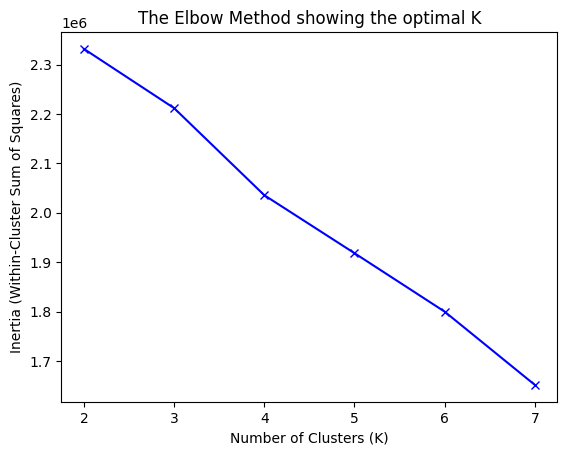

In [12]:
from sklearn.metrics import silhouette_score


inertia_values = []
K_range = range(2, 8)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

    cluster_labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels, metric='euclidean', sample_size=100_000) # reducing sample size due to computational complexity
    
    print(f"For K={k}, the Silhouette Score is: {score:.4f}")

# Plot the elbow curve
plt.plot(K_range, inertia_values, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal K')
None

In [50]:
kmeans = KMeans(n_clusters=6, random_state=random_state, n_init="auto")
kmeans.fit(X_scaled)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [51]:
# 4. Calculate distances to assigned centroids
# .transform() returns the distance from each point to EVERY centroid
distances_to_all_centroids = kmeans.transform(X_scaled)

# Isolate only the distance to the closest centroid (the assigned cluster)
labels = kmeans.labels_
anomaly_scores = distances_to_all_centroids[np.arange(len(X_scaled)), labels]

# 5. Define an anomaly threshold (e.g., top 3% furthest points)
threshold_percentage = 95
threshold = np.percentile(anomaly_scores, threshold_percentage)

# # 6. Flag anomalies
is_anomaly = anomaly_scores > threshold

# View results
anomaly_df = pd.DataFrame(df_resampled)
anomaly_df['Anomaly_Score'] = anomaly_scores
anomaly_df['Is_Anomaly'] = is_anomaly

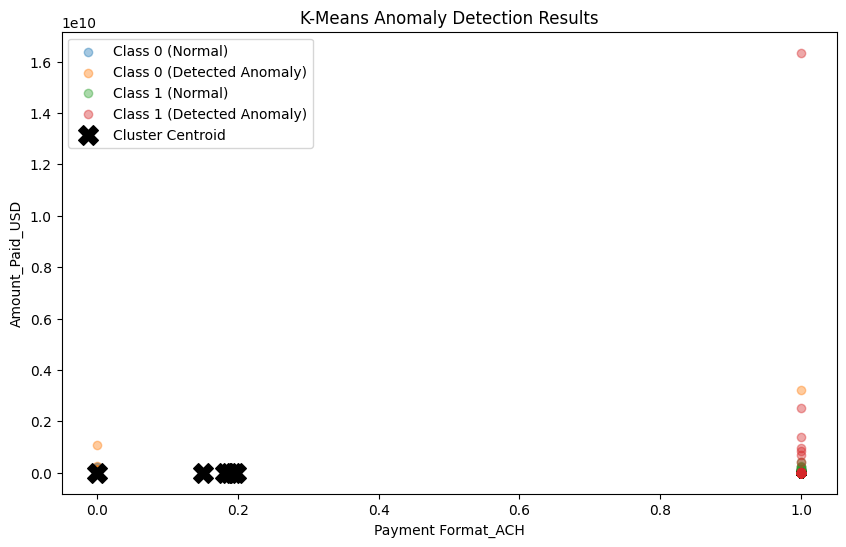

In [52]:
import matplotlib.pyplot as plt

# Separate the dataset into normal points and anomalies
normal_points = df_resampled[~is_anomaly]
anomaly_points = df_resampled[is_anomaly]

# Revert the scaled centroids back to the original data scale for accurate plotting
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X_resampled.columns)

feature_1 = 'Payment Format_ACH'
feature_2 = 'Amount_Paid_USD'

# Initialize the plot
plt.figure(figsize=(10, 6))

c0_normal = anomaly_df[(anomaly_df['Is Laundering'] == 0) & (anomaly_df['Is_Anomaly'] == False)]

# Group 2: Class 0, Flagged as Anomaly
c0_anomaly = anomaly_df[(anomaly_df['Is Laundering'] == 0) & (anomaly_df['Is_Anomaly'] == True)]

# Group 3: Class 1, Normal
c1_normal = anomaly_df[(anomaly_df['Is Laundering'] == 1) & (anomaly_df['Is_Anomaly'] == False)]

# Group 4: Class 1, Flagged as Anomaly
c1_anomaly = anomaly_df[(anomaly_df['Is Laundering'] == 1) & (anomaly_df['Is_Anomaly'] == True)]

# Group 1: Class 0 - Not detected as anomaly (Blue Circles)
plt.scatter(c0_normal[feature_1], c0_normal[feature_2], 
            alpha=0.4, 
            label='Class 0 (Normal)')

# Group 2: Class 0 - Detected as anomaly (Red Circles)
plt.scatter(c0_anomaly[feature_1], c0_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 0 (Detected Anomaly)')

# Group 3: Class 1 - Not detected as anomaly (Blue Squares)
plt.scatter(c1_normal[feature_1], c1_normal[feature_2], 
            alpha=0.4, 
            label='Class 1 (Normal)')

# Group 4: Class 1 - Detected as anomaly (Red Squares)
plt.scatter(c1_anomaly[feature_1], c1_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 1 (Detected Anomaly)')

plt.scatter(centroids_df[feature_1], centroids_df[feature_2], 
            c='black', marker='X', s=200, label='Cluster Centroid')

# Final formatting
plt.title('K-Means Anomaly Detection Results')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
None

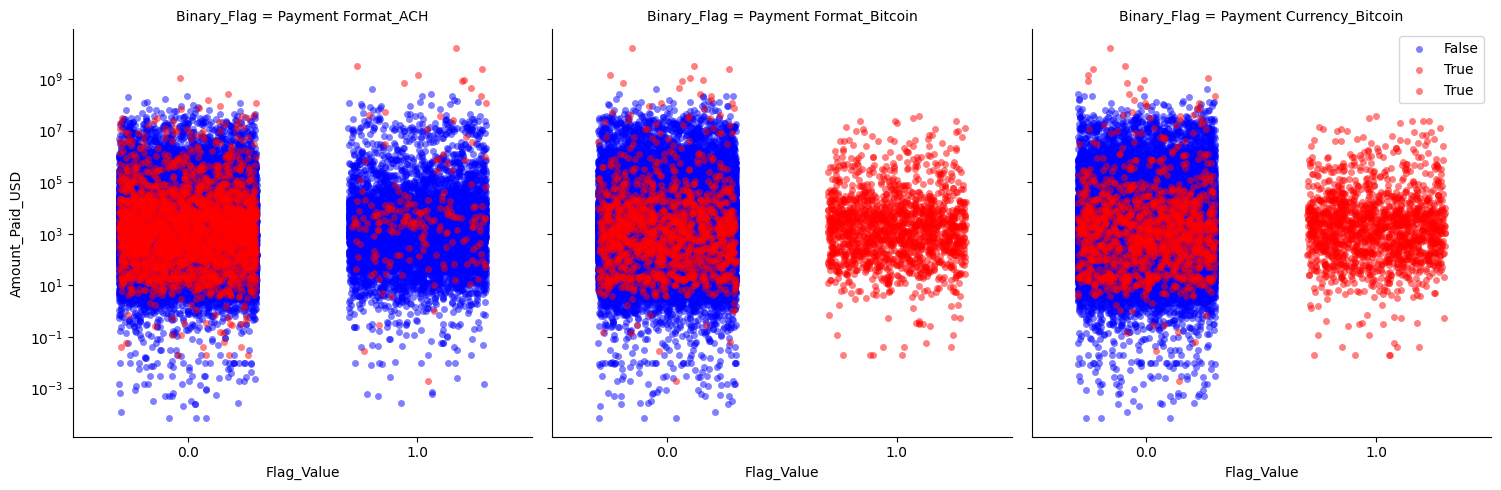

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt your dataframe to stack all binary flags into a single column
df_melted = anomaly_df.melt(
    id_vars=['Amount_Paid_USD', 'Is_Anomaly'], 
    value_vars=['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Currency_Bitcoin'],
    var_name='Binary_Flag', 
    value_name='Flag_Value'
)

# Plot a grid: Each column is a different flag, X-axis shows 0 or 1
g = sns.FacetGrid(df_melted, col="Binary_Flag", hue="Is_Anomaly", palette={0: "blue", 1: "red"}, height=5)
g.map_dataframe(sns.stripplot, x="Flag_Value", y="Amount_Paid_USD", jitter=0.3, alpha=0.5, dodge=True)

# Use a log scale since financial amounts span massive ranges
for ax in g.axes.flat:
    ax.set_yscale('log')

plt.legend()

plt.show()


In [44]:
import plotly.express as px

# Select the numeric column and all binary flag columns
columns_to_plot = ['Amount_Paid_USD', 'Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Currency_Bitcoin']

fig = px.parallel_coordinates(
    anomaly_df, 
    dimensions=columns_to_plot,
    color="Is_Anomaly",  # Highlights your anomalies in a separate color
    color_continuous_scale=px.colors.diverging.Tealrose
)
fig.show()


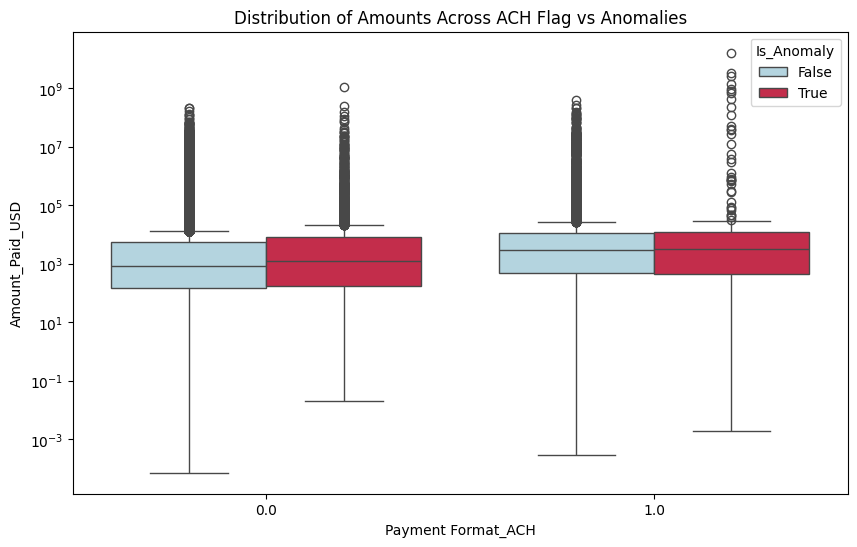

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Boxplot comparing ACH (0 vs 1) on the X axis, Amount on the Y axis
sns.boxplot(
    data=anomaly_df, 
    x="Payment Format_ACH", 
    y="Amount_Paid_USD", 
    hue="Is_Anomaly", # Splitting the boxes by anomaly classification
    palette={0: "lightblue", 1: "crimson"}
)

plt.yscale('log')
plt.title("Distribution of Amounts Across ACH Flag vs Anomalies")
plt.show()


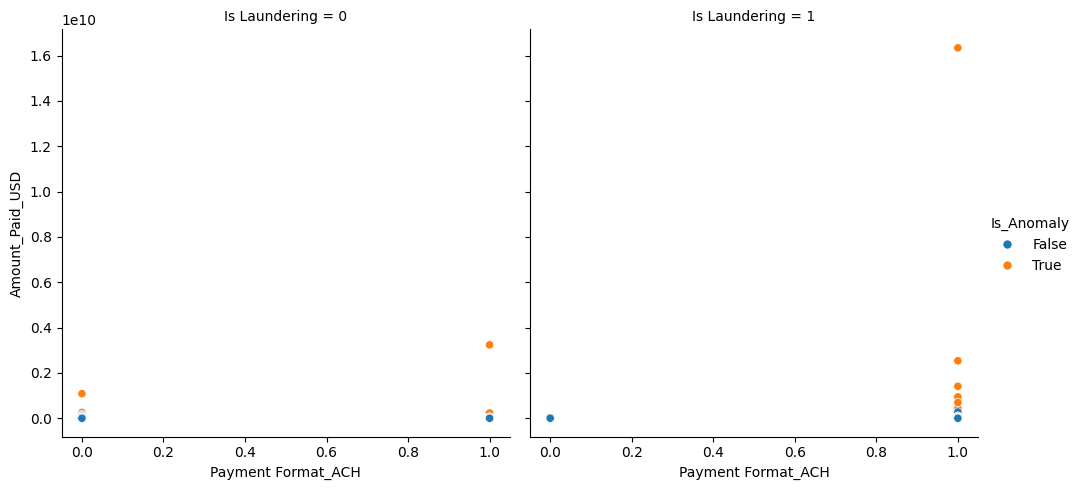

In [46]:
import seaborn as sns
sns.relplot(data=anomaly_df, x='Payment Format_ACH', y='Amount_Paid_USD', col='Is Laundering', hue='Is_Anomaly')

In [47]:
len(anomaly_df[anomaly_df['Is Laundering'] == 1]['Is Laundering'])

5177

In [48]:
len(anomaly_df[anomaly_df['Is_Anomaly'] == 1]['Is_Anomaly'])

2848

In [53]:
# Now we have seen visually how we might go about identifying anomalys and exploring them. Let's use metrics to see how accurate our identification was against the ground truth
print(classification_report(y_true=anomaly_df['Is Laundering'], y_pred=anomaly_df['Is_Anomaly']))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     51770
           1       0.14      0.08      0.10      5177

    accuracy                           0.87     56947
   macro avg       0.53      0.52      0.52     56947
weighted avg       0.84      0.87      0.86     56947



## PPP

### Import Dataset

In [54]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [55]:
df.dropna(inplace=True)

In [56]:
X = df.drop(columns='Fraud')
y = df['Fraud']

### Undersample

In [57]:
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.001, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
df_resampled = X_resampled.join(y_resampled)
print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968433, 1: 95})
Resampled dataset shape: Counter({0: 95000, 1: 95})


### Scaling

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

### K Means

For K=2, the Silhouette Score is: 0.1299
For K=3, the Silhouette Score is: 0.1171
For K=4, the Silhouette Score is: 0.1487
For K=5, the Silhouette Score is: 0.1408
For K=6, the Silhouette Score is: 0.1299
For K=7, the Silhouette Score is: 0.1341


Text(0.5, 1.0, 'The Elbow Method showing the optimal K')

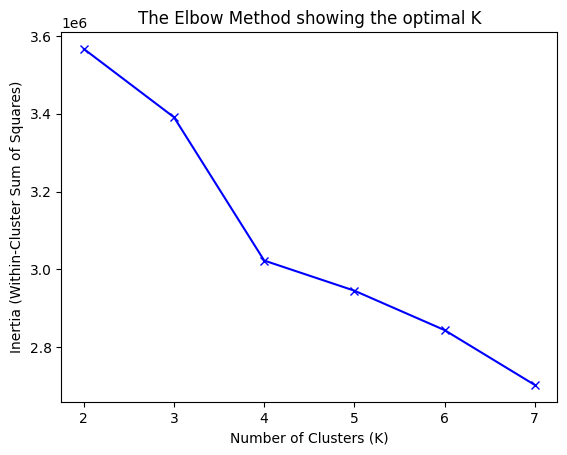

In [59]:
from sklearn.metrics import silhouette_score


inertia_values = []
K_range = range(2, 8)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

    cluster_labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels, metric='euclidean', sample_size=100_000) # reducing sample size due to computational complexity
    
    print(f"For K={k}, the Silhouette Score is: {score:.4f}")

# Plot the elbow curve
plt.plot(K_range, inertia_values, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal K')

In [60]:
kmeans = KMeans(n_clusters=4, random_state=random_state, n_init="auto")
kmeans.fit(X_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [61]:
# Calculate distances to assigned centroids
# .transform() returns the distance from each point to EVERY centroid
distances_to_all_centroids = kmeans.transform(X_scaled)

# Isolate only the distance to the closest centroid (the assigned cluster)
labels = kmeans.labels_
anomaly_scores = distances_to_all_centroids[np.arange(len(X_scaled)), labels]

# Define an anomaly threshold (e.g., top 3% furthest points)
threshold_percentage = 95
threshold = np.percentile(anomaly_scores, threshold_percentage)

# Flag anomalies
is_anomaly = anomaly_scores > threshold

# View results
anomaly_df = pd.DataFrame(df_resampled)
anomaly_df['Anomaly_Score'] = anomaly_scores
anomaly_df['Is_Anomaly'] = is_anomaly

In [62]:
anomaly_df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int,Fraud,Anomaly_Score,Is_Anomaly
294498,1.0,13.0,2.0,60,314685.0,314685.0,13.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1156.92,1613001600,1635465600,1637625600,0,4.753579,False
822500,0.0,47.0,2.0,24,780500.0,780500.0,46.0,1.0,1.0,1.0,...,0.0,0.0,0.0,8215.79,1586476800,1627430400,1629504000,0,4.302740,False
302411,1.0,14.0,2.0,60,238370.0,238370.0,14.0,0.0,0.0,0.0,...,0.0,0.0,0.0,10835.00,1610841600,1628640000,1628899200,0,3.349823,False
607094,0.0,37.0,2.0,24,3134100.0,3134100.0,33.0,1.0,1.0,1.0,...,0.0,0.0,0.0,12740.24,1586217600,1623369600,1626307200,0,4.568299,False
52948,1.0,5.0,2.0,60,882672.0,882672.0,37.0,1.0,0.0,1.0,...,0.0,0.0,0.0,18389.00,1615593600,1640131200,1642809600,0,3.568842,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915442,0.0,50.0,1.0,60,181055.0,181055.0,36.0,1.0,0.0,0.0,...,0.0,0.0,0.0,20117.22,1586736000,-2208988800,1586736000,1,4.800714,False
918753,0.0,50.0,1.0,60,192727.0,153334.0,44.0,1.0,0.0,0.0,...,0.0,0.0,0.0,17037.11,1588032000,-2208988800,1588032000,1,4.822960,False
924785,0.0,53.0,1.0,4,960000.0,960000.0,33.0,1.0,0.0,0.0,...,0.0,0.0,0.0,20000.00,1586822400,-2208988800,1586822400,1,5.623937,False
966758,0.0,56.0,1.0,41,634573.0,634573.0,47.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18663.91,1594684800,-2208988800,1594684800,1,4.932291,False


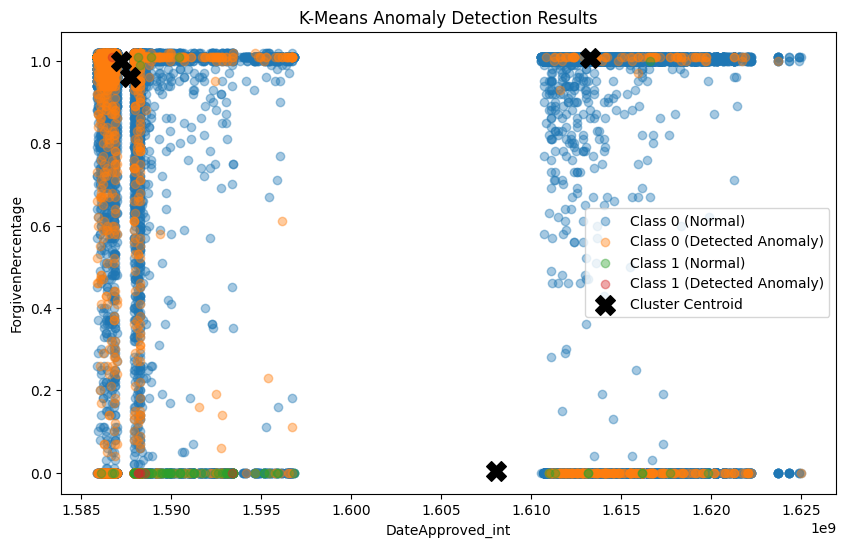

In [63]:
# Separate the dataset into normal points and anomalies
normal_points = df_resampled[~is_anomaly]
anomaly_points = df_resampled[is_anomaly]

# Revert the scaled centroids back to the original data scale for accurate plotting
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X_resampled.columns)

feature_1 = 'DateApproved_int'
feature_2 = 'ForgivenPercentage'

# Initialize the plot
plt.figure(figsize=(10, 6))

c0_normal = anomaly_df[(anomaly_df['Fraud'] == 0) & (anomaly_df['Is_Anomaly'] == False)]

# Group 2: Class 0, Flagged as Anomaly
c0_anomaly = anomaly_df[(anomaly_df['Fraud'] == 0) & (anomaly_df['Is_Anomaly'] == True)]

# Group 3: Class 1, Normal
c1_normal = anomaly_df[(anomaly_df['Fraud'] == 1) & (anomaly_df['Is_Anomaly'] == False)]

# Group 4: Class 1, Flagged as Anomaly
c1_anomaly = anomaly_df[(anomaly_df['Fraud'] == 1) & (anomaly_df['Is_Anomaly'] == True)]

# Group 1: Class 0 - Not detected as anomaly (Blue Circles)
plt.scatter(c0_normal[feature_1], c0_normal[feature_2], 
            alpha=0.4, 
            label='Class 0 (Normal)')

# Group 2: Class 0 - Detected as anomaly (Red Circles)
plt.scatter(c0_anomaly[feature_1], c0_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 0 (Detected Anomaly)')

# Group 3: Class 1 - Not detected as anomaly (Blue Squares)
plt.scatter(c1_normal[feature_1], c1_normal[feature_2], 
            alpha=0.4, 
            label='Class 1 (Normal)')

# Group 4: Class 1 - Detected as anomaly (Red Squares)
plt.scatter(c1_anomaly[feature_1], c1_anomaly[feature_2], 
            alpha=0.4, 
            label='Class 1 (Detected Anomaly)')

plt.scatter(centroids_df[feature_1], centroids_df[feature_2], 
            c='black', marker='X', s=200, label='Cluster Centroid')

# Final formatting
plt.title('K-Means Anomaly Detection Results')
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
None

In [64]:
len(anomaly_df[anomaly_df['Fraud'] == 1]['Fraud'])

95

In [65]:
len(anomaly_df[anomaly_df['Is_Anomaly'] == 1]['Is_Anomaly'])

4755

In [66]:
# Now we have seen visually how we might go about identifying anomalys and exploring them. Let's use metrics to see how accurate our identification was against the ground truth
print(classification_report(y_true=anomaly_df['Fraud'], y_pred=anomaly_df['Is_Anomaly']))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     95000
           1       0.00      0.06      0.00        95

    accuracy                           0.95     95095
   macro avg       0.50      0.51      0.49     95095
weighted avg       1.00      0.95      0.97     95095

